# **ExperimentNo:- 04**

#### **AIM:**
* Train a linear regression model on Boston Housing data, visualizing resiuals vs. predictions.

Explain the feature
Variables There are 14 attributes in each case of the dataset. They are:

* CRIM per capita crime rate by town
* ZN proportion of residential land zoned for lots over 25,000 sq.ft.
* INDUS proportion of non-retail business acres per town
* CHAS Charles River dummy variable (= 1 if tract bounds river; 0 otherwise)
* NOX nitric oxides concentration (parts per 10 million)
* RM average number of rooms per dwelling
* AGE proportion of owner-occupied units built prior to 1940
* DIS weighted distances to five Boston employment centres
* RAD index of accessibility to radial highways
* TAX full-value property-tax rate per 10 000 USD
* PTRATIO pupil-teacher ratio by town
* B 1000 (Bk - 0.63)^2 where Bk is the proportion of black people by town
* LSTAT % lower status of the population
* MEDV Median value of owner-occupied homes in $1000's

**import library**

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
%matplotlib inline

In [46]:
df = pd.read_csv("HousingData.csv")

In [47]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2


In [48]:
df.isnull().sum()

,0
CRIM,20
ZN,20
INDUS,20
CHAS,20
NOX,0
RM,0
AGE,20
DIS,0
RAD,0
TAX,0


In [49]:
df.shape

(506, 14)

In [50]:
df.isnull().mean()*100

,0
CRIM,3.952569
ZN,3.952569
INDUS,3.952569
CHAS,3.952569
NOX,0.000000
RM,0.000000
AGE,3.952569
DIS,0.000000
RAD,0.000000
TAX,0.000000


In [51]:
df.dropna(inplace=True)

In [52]:
df.shape

(394, 14)

In [53]:
df.isnull().sum()

,0
CRIM,0
ZN,0
INDUS,0
CHAS,0
NOX,0
RM,0
AGE,0
DIS,0
RAD,0
TAX,0


In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 394 entries, 0 to 504
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     394 non-null    float64
 1   ZN       394 non-null    float64
 2   INDUS    394 non-null    float64
 3   CHAS     394 non-null    float64
 4   NOX      394 non-null    float64
 5   RM       394 non-null    float64
 6   AGE      394 non-null    float64
 7   DIS      394 non-null    float64
 8   RAD      394 non-null    int64  
 9   TAX      394 non-null    int64  
 10  PTRATIO  394 non-null    float64
 11  B        394 non-null    float64
 12  LSTAT    394 non-null    float64
 13  MEDV     394 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 46.2 KB


In [55]:
df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,394.000000,394.000000,394.000000,394.000000,394.000000,394.000000,394.000000,394.000000,394.000000,394.000000,394.000000,394.000000,394.000000,394.000000
mean,3.690136,11.460660,11.000863,0.068528,0.553215,6.280015,68.932741,3.805268,9.403553,406.431472,18.537563,358.490939,12.769112,22.359645
std,9.202423,23.954082,6.908364,0.252971,0.113112,0.697985,27.888705,2.098571,8.633451,168.312419,2.166460,89.283295,7.308430,9.142979
min,0.006320,0.000000,0.460000,0.000000,0.389000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,2.600000,1.730000,5.000000
25%,0.081955,0.000000,5.130000,0.000000,0.453000,5.879250,45.475000,2.110100,4.000000,280.250000,17.400000,376.707500,7.125000,16.800000
50%,0.268880,0.000000,8.560000,0.000000,0.538000,6.201500,77.700000,3.199200,5.000000,330.000000,19.100000,392.190000,11.300000,21.050000
75%,3.435973,12.500000,18.100000,0.000000,0.624000,6.605500,94.250000,5.116700,24.000000,666.000000,20.200000,396.900000,17.117500,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


### Exploratory data Analysis

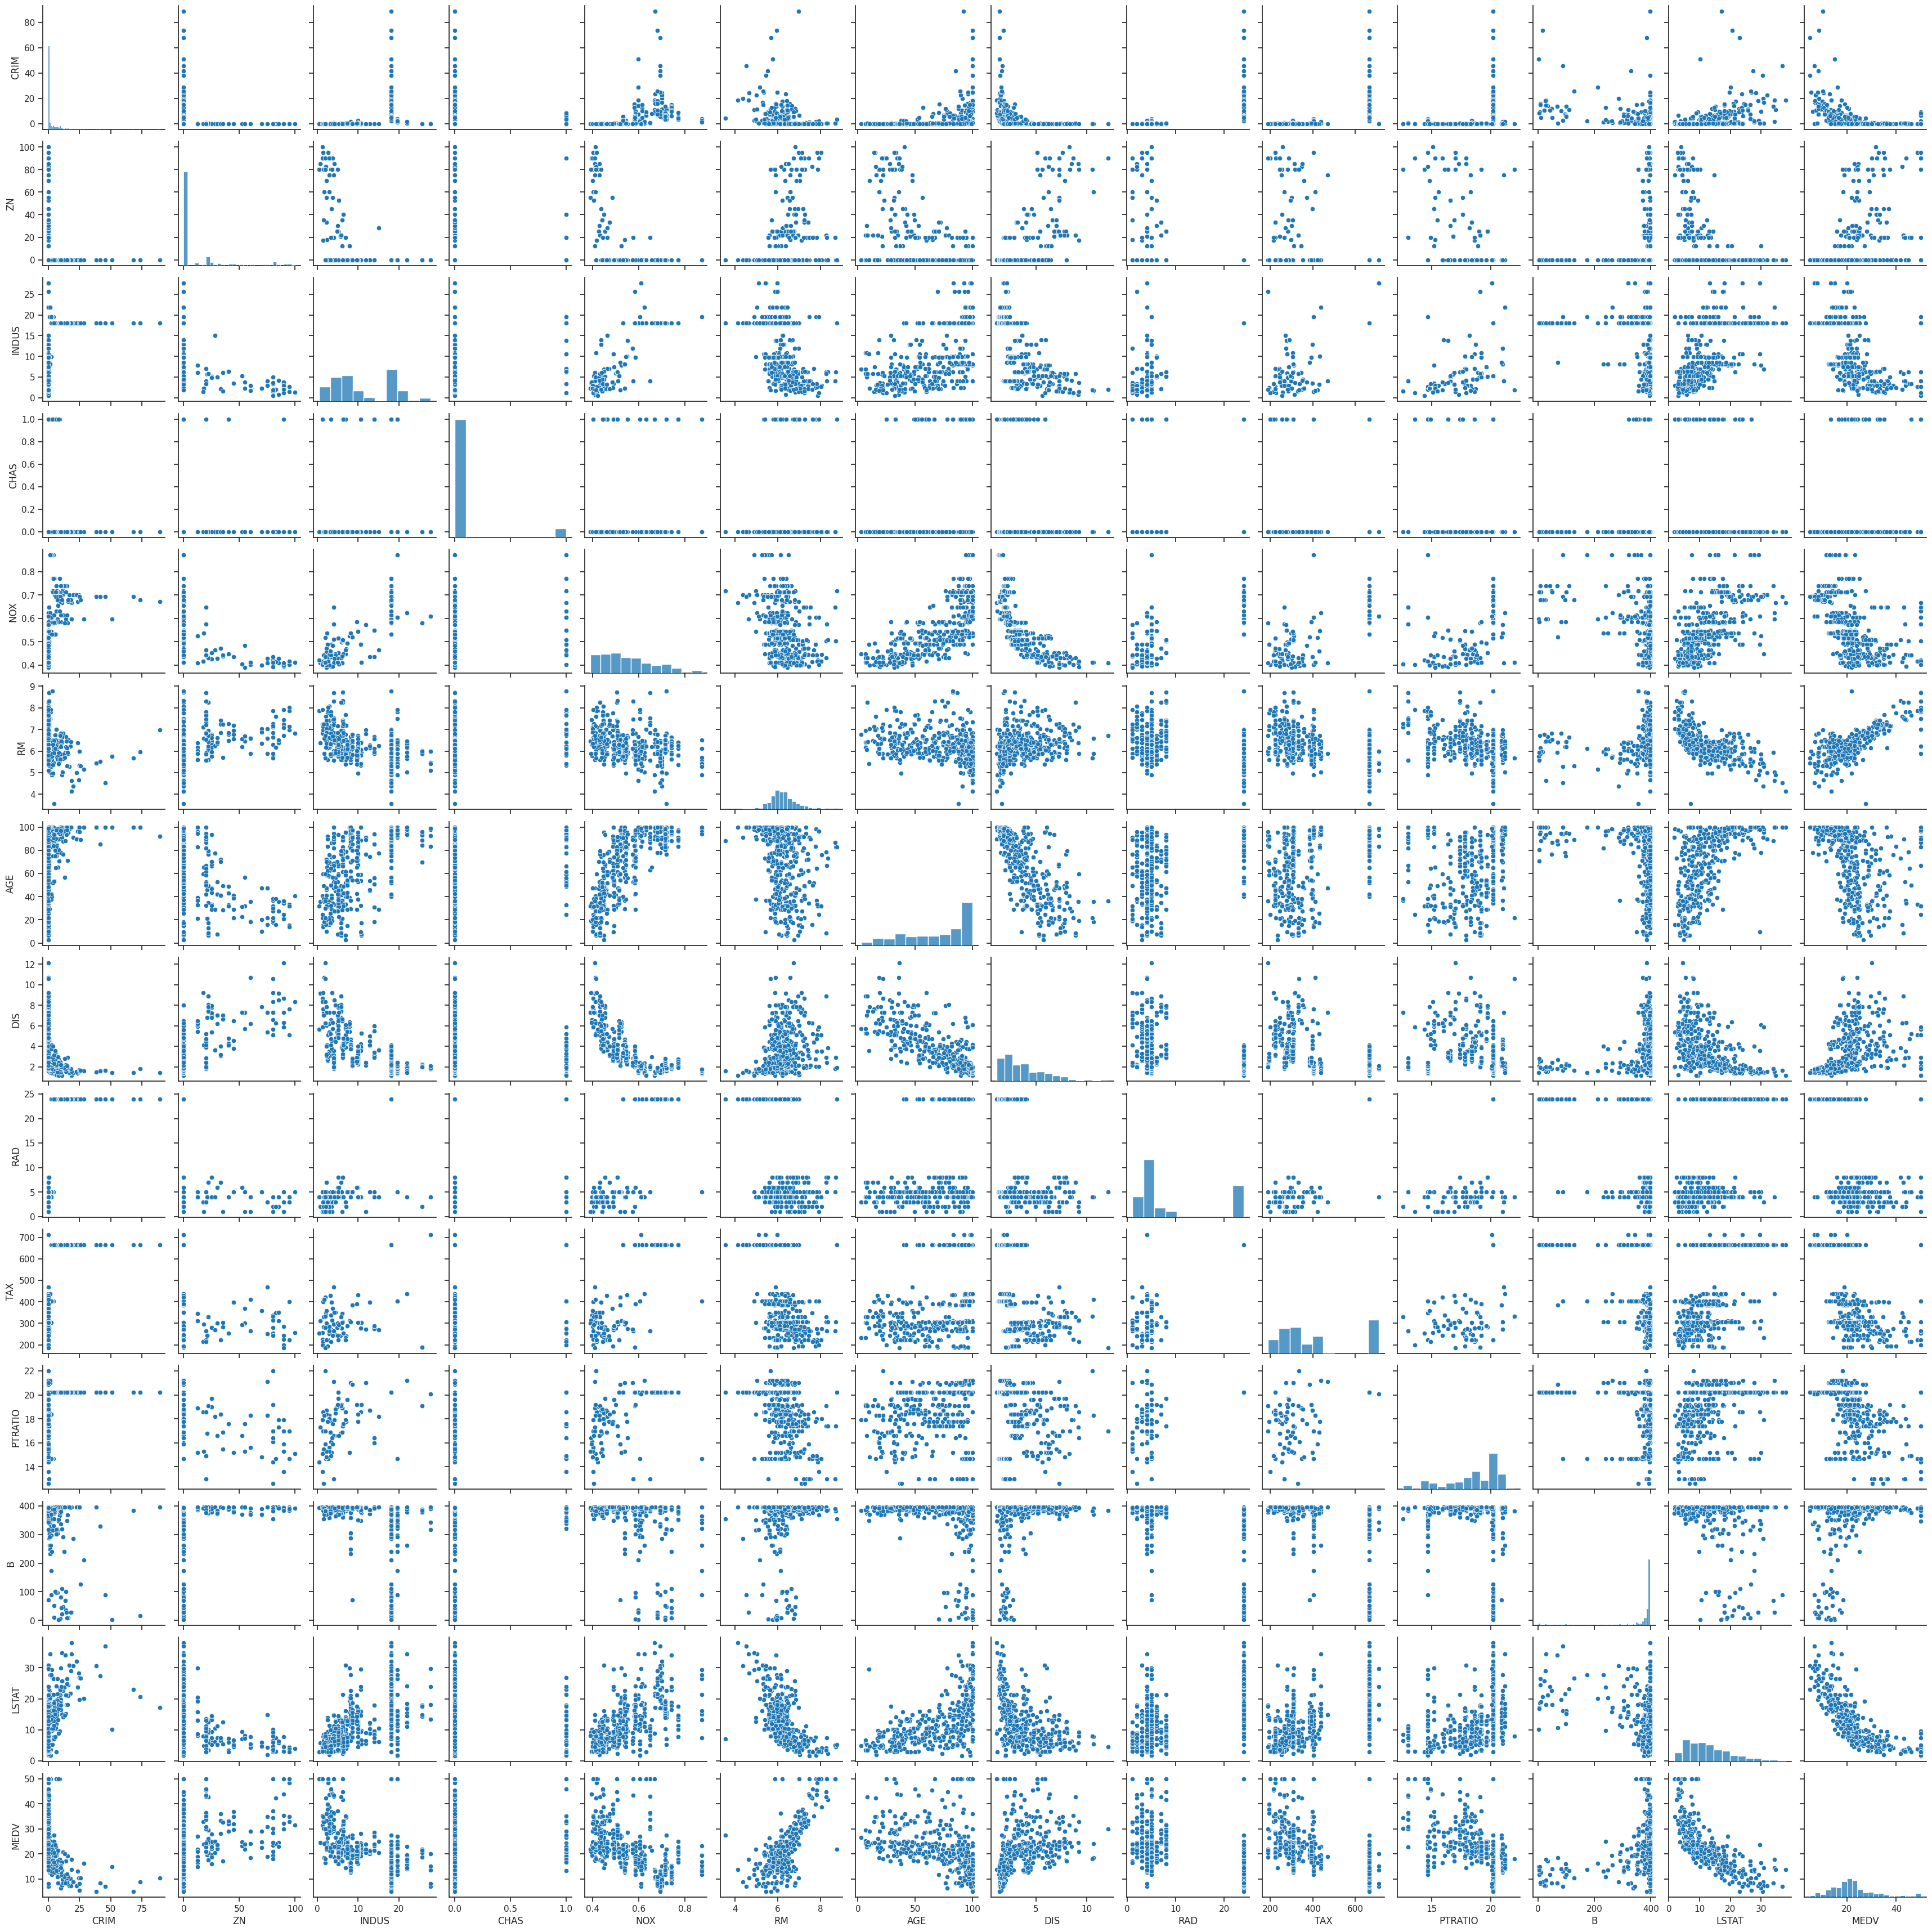

In [56]:
sns.set_context("notebook")
sns.pairplot(df)

### Distribution Plot

/tmp/ipython-input-2504084824.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['MEDV'])


<Axes: xlabel='MEDV', ylabel='Density'>

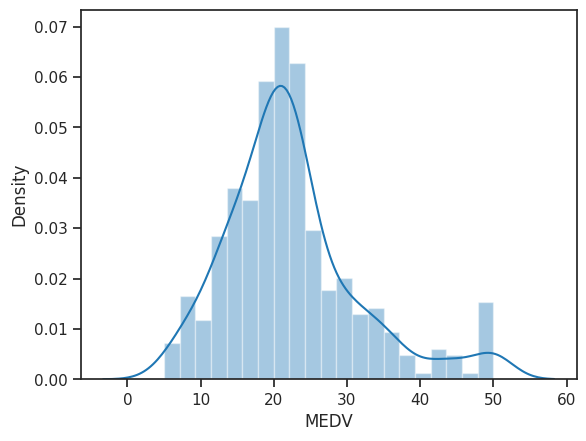

In [57]:
sns.set_style('ticks')
sns.set_context('notebook')
sns.distplot(df['MEDV'])

### **correlation**

<Axes: >

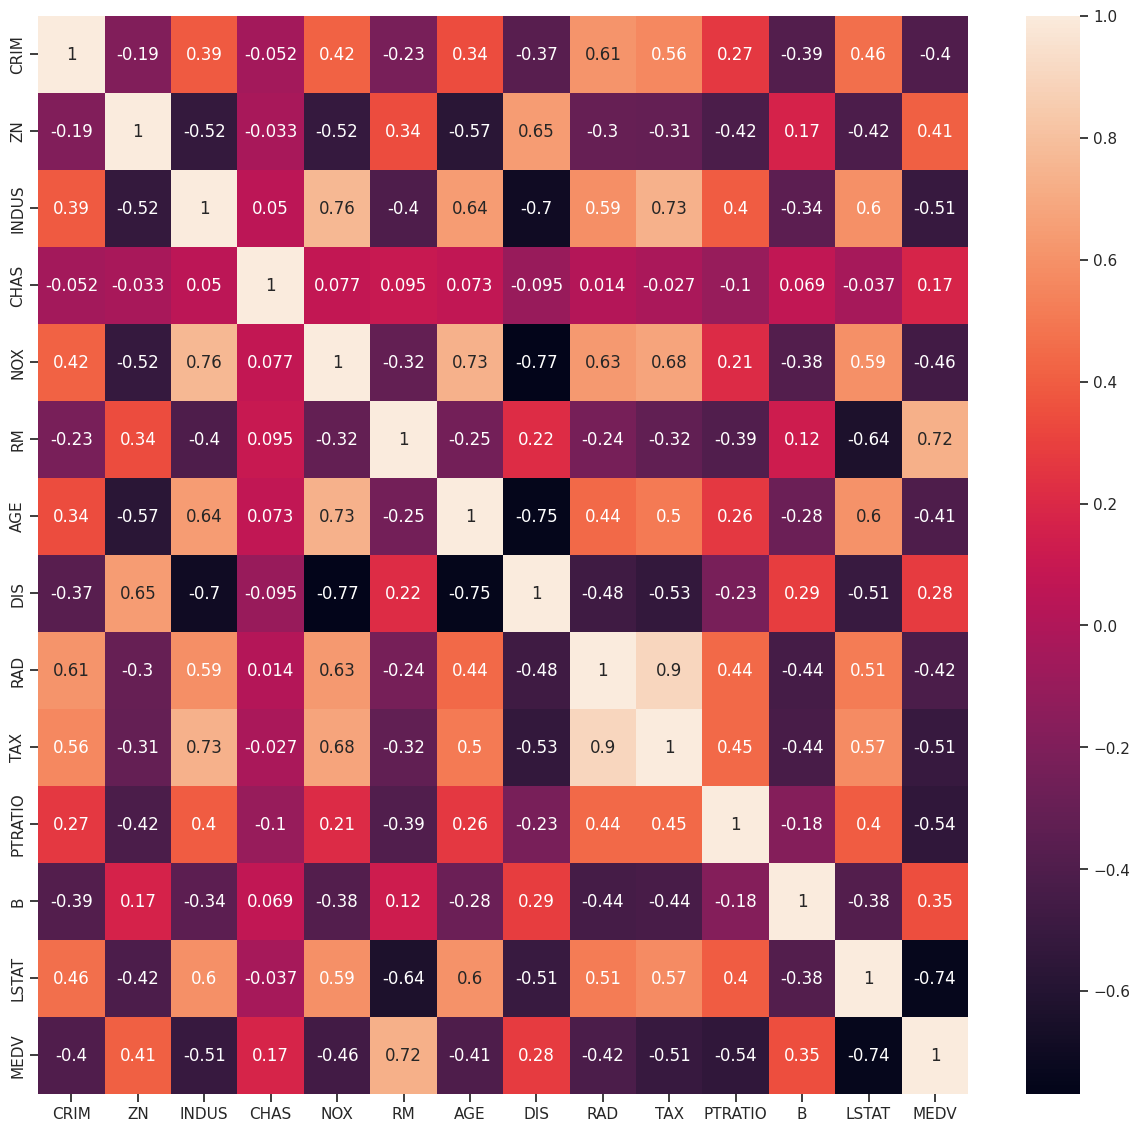

In [58]:
plt.figure(figsize=(15,14))
sns.heatmap(df.corr(), annot=True)

### Regression plot

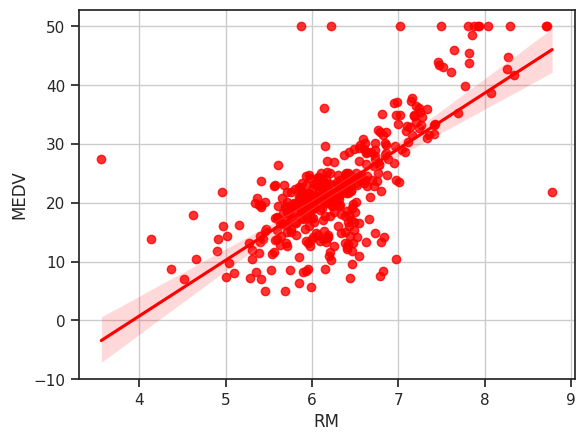

In [59]:
sns.set_context('notebook')
sns.regplot(x='RM', y='MEDV', data=df, color = 'red')
plt.grid()

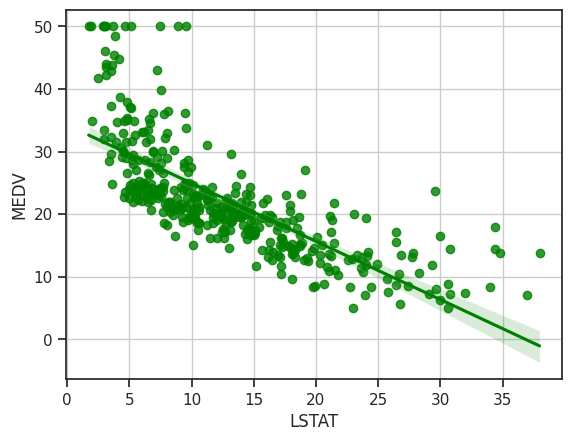

In [60]:
sns.set_style('ticks')
sns.set_context('notebook')
sns.regplot(x='LSTAT', y= 'MEDV', data=df, color = 'green')
plt.grid()

In [61]:
X= df.drop(columns='MEDV', axis=1)
y = df['MEDV']

#### Splitting Data

In [62]:
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size= 0.2, random_state=1234)

### Training a Model

In [63]:
l_model = LinearRegression()
l_model.fit(X_train,y_train)

LinearRegression()

In [64]:
y_pred = l_model.predict(X_test)

## Model Evaluation

In [65]:
print(f"Accuracy Score: {round(l_model.score(X_test,y_test),2)}")
print(f"MAE: {round(mean_absolute_error(y_test, y_pred),5)}")

Accuracy Score: 0.77
MAE: 2.9578


In [66]:
print(f"Intercept: {l_model.intercept_}")
print(f"Coefficient: {l_model.coef_}")

Intercept: 34.35783974025128
Coefficient: [-1.20959614e-01  5.50098735e-02  5.30044773e-02  2.14899611e+00
 -1.89673652e+01  4.24994451e+00 -1.42539961e-02 -1.52781644e+00
  2.89702086e-01 -1.15361586e-02 -9.69232954e-01  9.89672467e-03
 -4.45581826e-01]


In [67]:
df_a_p = pd.DataFrame({
    'Actual':y_test,
    'Predicted':y_pred
})

df_a_p.head()

,Actual,Predicted
48,14.4,9.846320
54,18.9,16.420590
329,22.6,24.760234
69,20.9,21.078513
342,16.5,22.014585


### Plotting KDE for Observed vs. Predicted Values

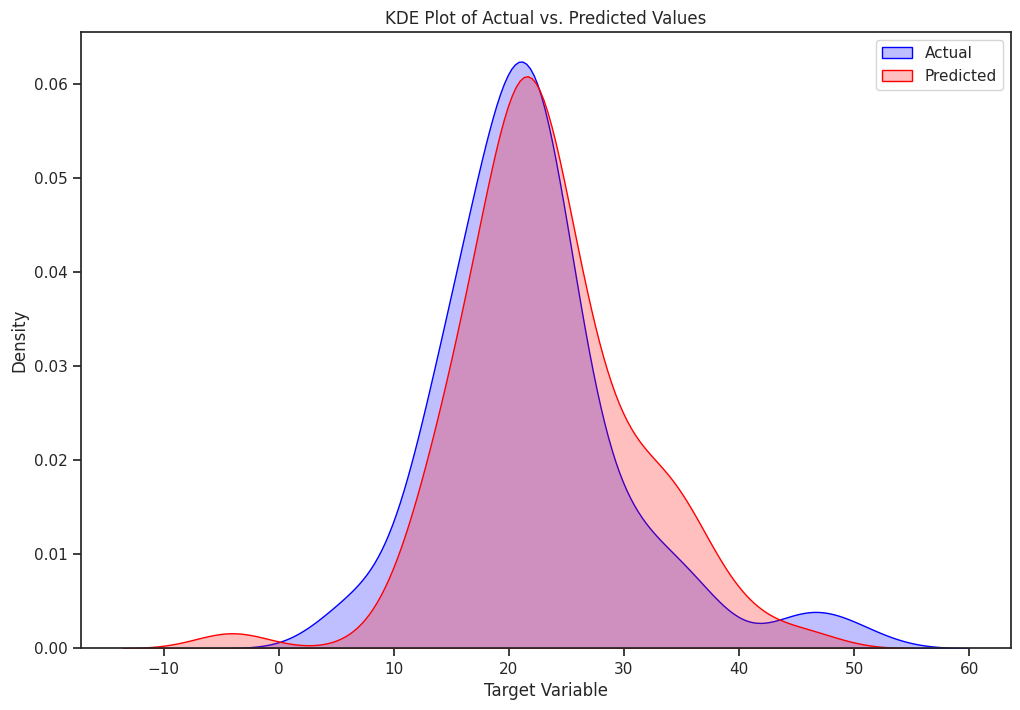

In [68]:
plt.figure(figsize= (12,8))
sns.set_context('notebook')
sns.kdeplot(y_test, label = 'Actual', fill = True, color = 'blue')
sns.kdeplot(y_pred, label = 'Predicted', fill = True, color = 'red')
plt.title("KDE Plot of Actual vs. Predicted Values")
plt.xlabel('Target Variable')
plt.ylabel('Density')
plt.legend()
plt.show()